In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alessiocorrado99/animals10/translate.py
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-mdvOxIWAyReAoEJcMk5z4wHaJ4.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-TPYKs3XId_sMgp_6LLA6JgDMEy.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-jlVRrokx7Vu1axi8OnTX2AHaE2.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-F4QVZ71QagiynDMnFNxJUAHaEK.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-UFtUZnXq0JHZo5R8UuF80wHaFj.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-irWuWeIWd3Hm3BWGd0OEsQHaGO.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-Y-hB14A3coI7TEgrEew0UAHaFj.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-KqeKmYfnRwKd89nLg8_zRAHaHb.jpeg
/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cavallo/OIP-s40xdXSQY099gt1hLGlzAwHaFP.jpeg
/kaggle/input/datas

In [9]:

# ── CELL 1 : Imports ─────────────────────────────────────────
import os, json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from collections import defaultdict

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11

RAW_DIR    = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img"
OUTPUT_DIR = "/kaggle/working/eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ITALIAN_TO_ENGLISH = {
    "cane":"dog","cavallo":"horse","elefante":"elephant",
    "farfalla":"butterfly","gallina":"chicken","gatto":"cat",
    "mucca":"cow","pecora":"sheep","ragno":"spider","scoiattolo":"squirrel",
}
CLASS_NAMES = sorted(ITALIAN_TO_ENGLISH.values())

In [10]:

# ── CELL 2 : Scan every image ────────────────────────────────
# We go through every file and collect:
#   - count per class
#   - image width & height
#   - corrupt file flag
#   - MD5 hash (for duplicate detection)

records   = []   # one dict per file
seen_hash = {}   # hash → first filepath

print("Scanning dataset — this takes ~2 minutes...")

for it, en in ITALIAN_TO_ENGLISH.items():
    class_dir = Path(RAW_DIR) / it
    files = list(class_dir.glob("*"))

    for fpath in tqdm(files, desc=en, leave=False):
        if fpath.suffix.lower() not in {".jpg",".jpeg",".png",".bmp"}:
            continue

        rec = {"class": en, "path": str(fpath),
               "corrupt": False, "duplicate": False,
               "width": None, "height": None, "filesize_kb": None}

        # filesize
        rec["filesize_kb"] = round(fpath.stat().st_size / 1024, 2)

        # MD5 hash — detect duplicates
        md5 = hashlib.md5(fpath.read_bytes()).hexdigest()
        if md5 in seen_hash:
            rec["duplicate"] = True
        else:
            seen_hash[md5] = str(fpath)

        # image validity + dimensions
        try:
            with Image.open(fpath) as img:
                img.verify()
            with Image.open(fpath) as img:
                rec["width"], rec["height"] = img.size
        except Exception:
            rec["corrupt"] = True

        records.append(rec)

df = pd.DataFrame(records)
print(f"\nTotal files scanned : {len(df)}")
print(f"Corrupt images      : {df['corrupt'].sum()}")
print(f"Duplicate images    : {df['duplicate'].sum()}")
print(f"Clean images        : {(~df['corrupt'] & ~df['duplicate']).sum()}")


Scanning dataset — this takes ~2 minutes...


dog:   0%|          | 0/4863 [00:00<?, ?it/s]

horse:   0%|          | 0/2623 [00:00<?, ?it/s]

elephant:   0%|          | 0/1446 [00:00<?, ?it/s]

butterfly:   0%|          | 0/2112 [00:00<?, ?it/s]

...

cow:   0%|          | 0/1866 [00:00<?, ?it/s]

sheep:   0%|          | 0/1820 [00:00<?, ?it/s]

spider:   0%|          | 0/4821 [00:00<?, ?it/s]

squirrel:   0%|          | 0/1862 [00:00<?, ?it/s]


Total files scanned : 26179
Corrupt images      : 0
Duplicate images    : 0
Clean images        : 26179


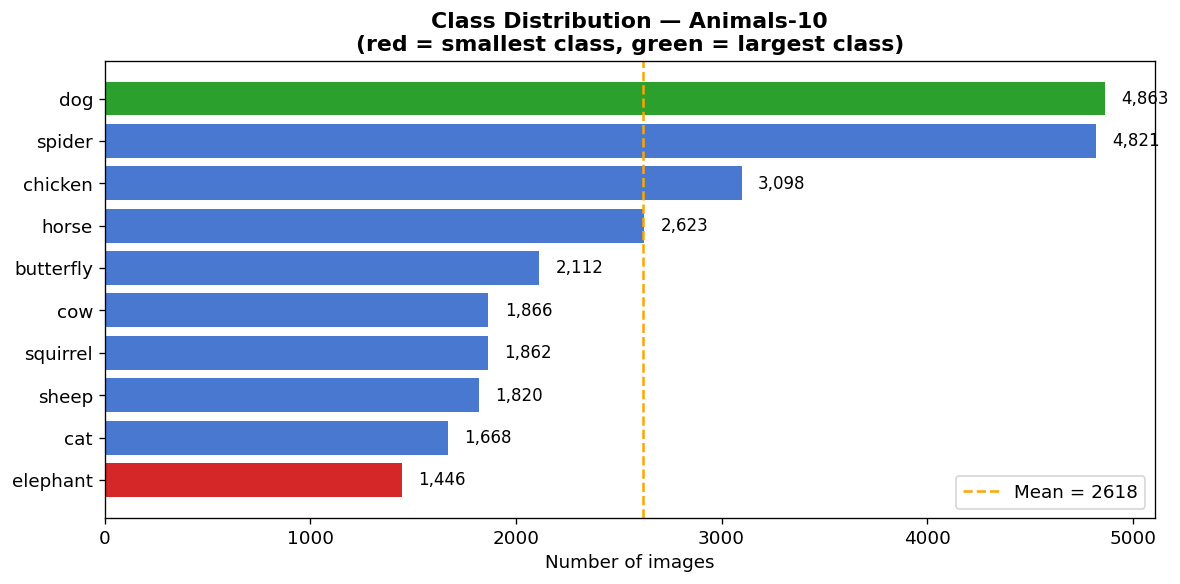


Imbalance ratio (max/min) : 3.36x
Largest class  : dog (4,863 images)
Smallest class : elephant (1,446 images)

  *** IMBALANCE DETECTED (ratio > 1.5x) ***
  Decision: Apply WeightedRandomSampler + class-weighted loss


In [11]:

# ── CELL 3 : EDA FINDING #1 — Class Distribution ─────────────
clean_df = df[~df["corrupt"] & ~df["duplicate"]]
counts   = clean_df["class"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, counts.values,
               color=["#d62728" if v == counts.min()
                      else "#2ca02c" if v == counts.max()
                      else "#4878cf" for v in counts.values])

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)

ax.axvline(counts.mean(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean = {counts.mean():.0f}")
ax.set_xlabel("Number of images")
ax.set_title("Class Distribution — Animals-10\n"
             "(red = smallest class, green = largest class)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_distribution.png",
            bbox_inches="tight")
plt.show()

# Key metric: imbalance ratio
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min) : {imbalance_ratio:.2f}x")
print(f"Largest class  : {counts.idxmax()} ({counts.max():,} images)")
print(f"Smallest class : {counts.idxmin()} ({counts.min():,} images)")
if imbalance_ratio > 1.5:
    print(f"\n  *** IMBALANCE DETECTED (ratio > 1.5x) ***")
    print(f"  Decision: Apply WeightedRandomSampler + class-weighted loss")

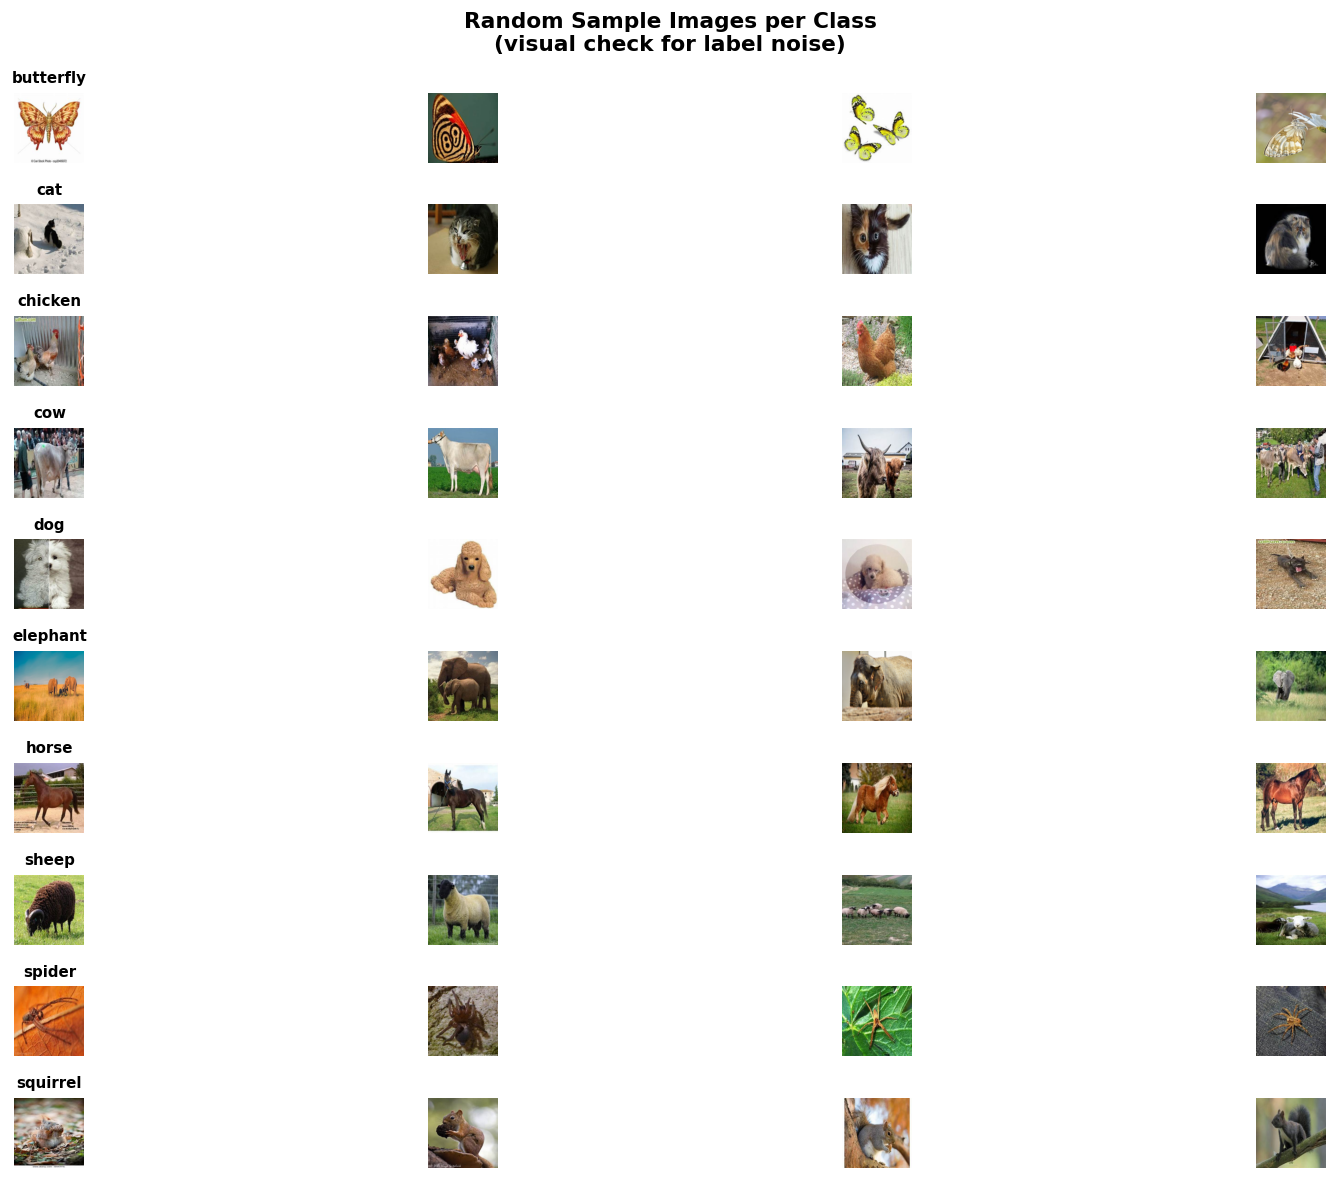

Visual inspection: check above for any obviously wrong labels.


In [12]:

# ── CELL 4 : EDA FINDING #2 — Sample Images per Class ────────
# Visual check for mislabelled images

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Random Sample Images per Class\n"
             "(visual check for label noise)", fontweight="bold", fontsize=13)

for idx, cls in enumerate(sorted(clean_df["class"].unique())):
    cls_df  = clean_df[clean_df["class"] == cls].sample(
                  min(4, len(clean_df[clean_df["class"] == cls])),
                  random_state=42)
    for j, (_, row) in enumerate(cls_df.iterrows()):
        ax = fig.add_subplot(10, 4, idx*4 + j + 1)
        try:
            img = Image.open(row["path"]).convert("RGB")
            img = img.resize((128, 128))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "error", ha="center")
        ax.set_title(cls if j == 0 else "", fontsize=9, fontweight="bold")
        ax.axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_sample_images.png", bbox_inches="tight")
plt.show()
print("Visual inspection: check above for any obviously wrong labels.")

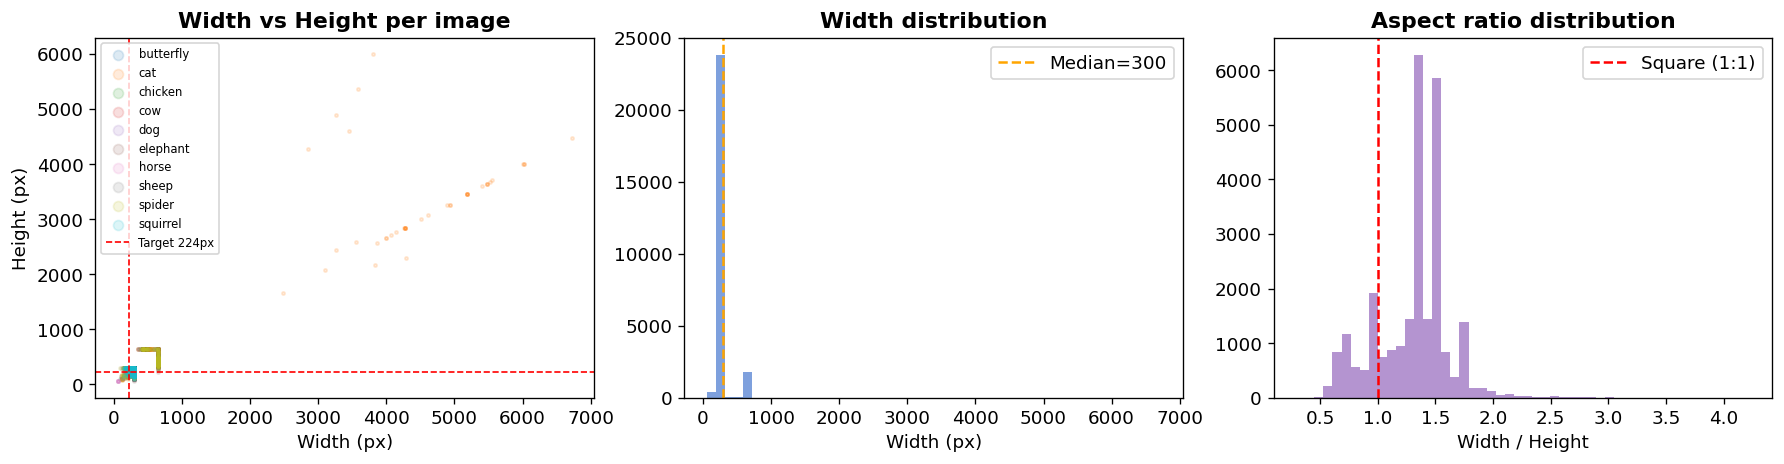


Width  — min:60  max:6720  median:300
Height — min:57  max:6000  median:225

  Decision: Resize all images to 224×224 (EfficientNet-B3 standard input size)


In [13]:

# ── CELL 5 : EDA FINDING #3 — Image Size Distribution ────────
# Shows how much the raw sizes vary — justifies resizing to 224

valid_df = clean_df.dropna(subset=["width", "height"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter: width vs height coloured by class
for cls in CLASS_NAMES:
    sub = valid_df[valid_df["class"] == cls]
    axes[0].scatter(sub["width"], sub["height"], alpha=0.15, s=4, label=cls)
axes[0].set_xlabel("Width (px)"); axes[0].set_ylabel("Height (px)")
axes[0].set_title("Width vs Height per image", fontweight="bold")
axes[0].axvline(224, color="red", linestyle="--", linewidth=1, label="Target 224px")
axes[0].axhline(224, color="red", linestyle="--", linewidth=1)
axes[0].legend(fontsize=7, markerscale=3)

# Width histogram
axes[1].hist(valid_df["width"],  bins=50, color="#4878cf", alpha=0.7)
axes[1].axvline(valid_df["width"].median(), color="orange",
                linestyle="--", label=f"Median={valid_df['width'].median():.0f}")
axes[1].set_title("Width distribution", fontweight="bold")
axes[1].set_xlabel("Width (px)"); axes[1].legend()

# Aspect ratio histogram
valid_df["aspect"] = valid_df["width"] / valid_df["height"]
axes[2].hist(valid_df["aspect"], bins=50, color="#9467bd", alpha=0.7)
axes[2].axvline(1.0, color="red", linestyle="--", label="Square (1:1)")
axes[2].set_title("Aspect ratio distribution", fontweight="bold")
axes[2].set_xlabel("Width / Height"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_image_sizes.png", bbox_inches="tight")
plt.show()

print(f"\nWidth  — min:{valid_df['width'].min()}  "
      f"max:{valid_df['width'].max()}  "
      f"median:{valid_df['width'].median():.0f}")
print(f"Height — min:{valid_df['height'].min()}  "
      f"max:{valid_df['height'].max()}  "
      f"median:{valid_df['height'].median():.0f}")
print(f"\n  Decision: Resize all images to 224×224 "
      f"(EfficientNet-B3 standard input size)")


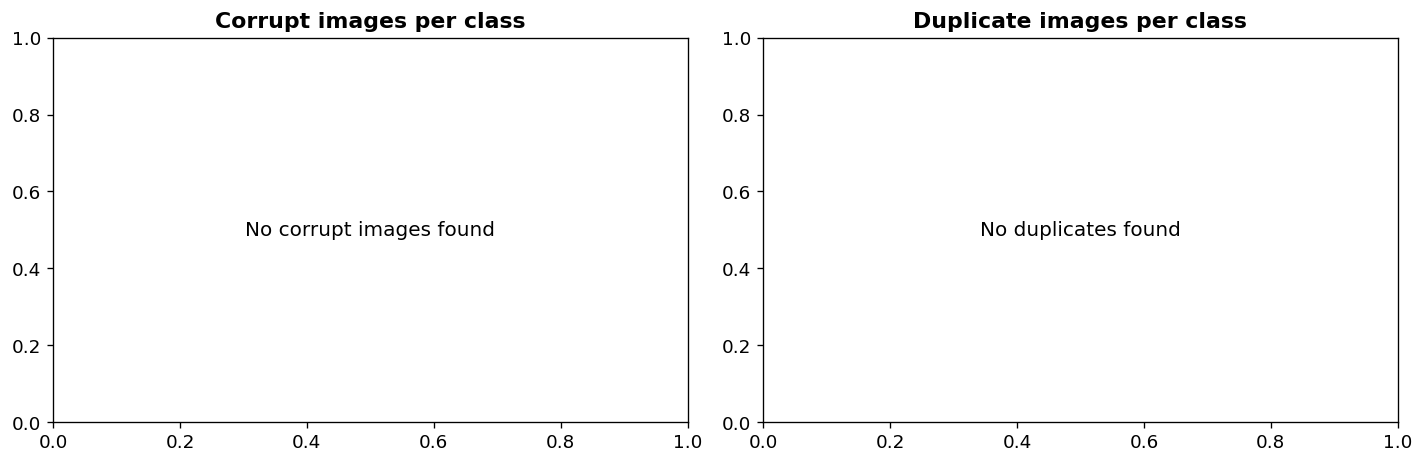

In [14]:

# ── CELL 6 : EDA FINDING #4 — Corrupt & Duplicate Report ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Corrupt per class
corrupt_counts = df[df["corrupt"]]["class"].value_counts()
if len(corrupt_counts):
    axes[0].bar(corrupt_counts.index, corrupt_counts.values, color="#d62728")
    axes[0].set_title("Corrupt images per class", fontweight="bold")
    axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
else:
    axes[0].text(0.5, 0.5, "No corrupt images found",
                 ha="center", va="center", fontsize=12)
    axes[0].set_title("Corrupt images per class", fontweight="bold")

# Duplicate per class
dup_counts = df[df["duplicate"]]["class"].value_counts()
if len(dup_counts):
    axes[1].bar(dup_counts.index, dup_counts.values, color="#ff7f0e")
    axes[1].set_title("Duplicate images per class", fontweight="bold")
    axes[1].set_xlabel("Class"); axes[1].set_ylabel("Count")
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
else:
    axes[1].text(0.5, 0.5, "No duplicates found",
                 ha="center", va="center", fontsize=12)
    axes[1].set_title("Duplicate images per class", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_data_quality.png", bbox_inches="tight")
plt.show()


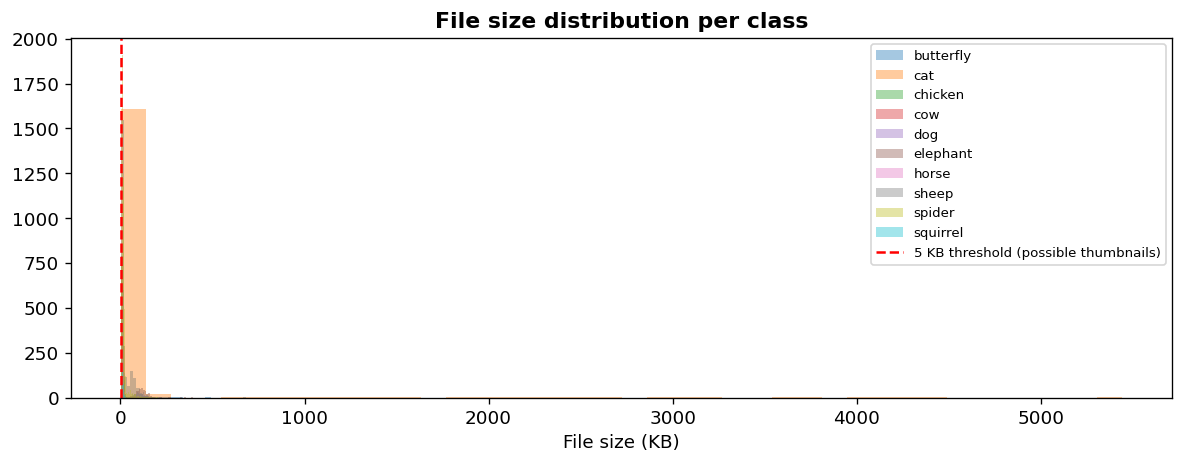

Suspiciously small files (<5 KB): 197
class
spider       87
cat          39
dog          22
butterfly    11
horse        11
squirrel     11
chicken      10
sheep         4
cow           2
Name: count, dtype: int64


In [15]:

# ── CELL 7 : EDA FINDING #5 — File Size Distribution ─────────
# Unusually small files (<5 KB) are often corrupt thumbnails
# Unusually large files may be duplicated high-res scans

fig, ax = plt.subplots(figsize=(10, 4))
for cls in CLASS_NAMES:
    sub = clean_df[clean_df["class"] == cls]
    ax.hist(sub["filesize_kb"], bins=40, alpha=0.4, label=cls)
ax.axvline(5, color="red", linestyle="--", linewidth=1.5,
           label="5 KB threshold (possible thumbnails)")
ax.set_xlabel("File size (KB)")
ax.set_title("File size distribution per class", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_file_sizes.png", bbox_inches="tight")
plt.show()

tiny = clean_df[clean_df["filesize_kb"] < 5]
print(f"Suspiciously small files (<5 KB): {len(tiny)}")
if len(tiny):
    print(tiny["class"].value_counts())


In [16]:

# ── CELL 8 : EDA Summary & Decision Log ──────────────────────
# This is the most important output — it documents WHY we made
# each training decision based on what the data showed us.

summary = {
    "total_raw_files"     : int(len(df)),
    "corrupt_files"       : int(df["corrupt"].sum()),
    "duplicate_files"     : int(df["duplicate"].sum()),
    "clean_files"         : int((~df["corrupt"] & ~df["duplicate"]).sum()),
    "class_counts"        : counts.to_dict(),
    "imbalance_ratio"     : round(float(imbalance_ratio), 3),
    "median_width"        : int(valid_df["width"].median()),
    "median_height"       : int(valid_df["height"].median()),
    "decisions": {
        "WeightedRandomSampler":
            f"Applied — imbalance ratio is {imbalance_ratio:.2f}x (threshold 1.5x). "
            f"Largest: {counts.idxmax()} ({counts.max()}), "
            f"Smallest: {counts.idxmin()} ({counts.min()})",
        "ClassWeightedLoss":
            "Applied — reinforces sampler, penalises errors on minority classes more",
        "CorruptFilter":
            f"Applied — {int(df['corrupt'].sum())} corrupt files removed before training",
        "DuplicateRemoval":
            f"Applied — {int(df['duplicate'].sum())} duplicates removed (MD5 hash)",
        "ResizeTo224":
            f"Applied — raw sizes vary from {int(valid_df['width'].min())} to "
            f"{int(valid_df['width'].max())}px width; "
            f"EfficientNet-B3 requires 224×224",
        "HeavyAugmentation":
            "Applied — high size variance and real-world photo variation "
            "requires strong augmentation to generalise",
    }
}

with open(f"{OUTPUT_DIR}/eda_report.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("  EDA SUMMARY")
print("="*60)
print(f"  Total raw files    : {summary['total_raw_files']:,}")
print(f"  Corrupt            : {summary['corrupt_files']}")
print(f"  Duplicates         : {summary['duplicate_files']}")
print(f"  Clean for training : {summary['clean_files']:,}")
print(f"  Imbalance ratio    : {summary['imbalance_ratio']}x")
print()
print("  Training decisions made from EDA:")
for k, v in summary["decisions"].items():
    print(f"  [{k}]")
    print(f"    {v}")
print()
print(f"  All plots saved to {OUTPUT_DIR}/")
print(f"  eda_report.json saved (used by training notebook)")
print("="*60)


  EDA SUMMARY
  Total raw files    : 26,179
  Corrupt            : 0
  Duplicates         : 0
  Clean for training : 26,179
  Imbalance ratio    : 3.363x

  Training decisions made from EDA:
  [WeightedRandomSampler]
    Applied — imbalance ratio is 3.36x (threshold 1.5x). Largest: dog (4863), Smallest: elephant (1446)
  [ClassWeightedLoss]
    Applied — reinforces sampler, penalises errors on minority classes more
  [CorruptFilter]
    Applied — 0 corrupt files removed before training
  [DuplicateRemoval]
    Applied — 0 duplicates removed (MD5 hash)
  [ResizeTo224]
    Applied — raw sizes vary from 60 to 6720px width; EfficientNet-B3 requires 224×224
  [HeavyAugmentation]
    Applied — high size variance and real-world photo variation requires strong augmentation to generalise

  All plots saved to /kaggle/working/eda_outputs/
  eda_report.json saved (used by training notebook)
